In [30]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open("./data/human_activity_train.csv", encoding="utf-8") as f:
    header = next(csv.reader(f))

feature_name_org = header[:-2]

feature_name_df = pd.DataFrame({'column_index': range(1, len(feature_name_org) + 1),
                                'column_name': feature_name_org})

feature_name = feature_name_df.iloc[:, 1].values.tolist()

print('전체 피쳐 개수:', len(feature_name))
print('전체 피처명에서 10개만', feature_name[:10])

전체 피쳐 개수: 561
전체 피처명에서 10개만 ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [31]:
feature_dup_df = feature_name_df.groupby("column_name").count()
print(feature_dup_df[feature_dup_df["column_index"] > 1].count())
feature_dup_df[feature_dup_df["column_index"] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [32]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby("column_name").cumcount(),
                                  columns=["dup_cnt"])
    feature_dup_df = feature_dup_df.reset_index() # 과거의 인덱스를 가지고있는 경우가 있어서 없애줄 때 사용

    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how="outer")
    new_feature_name_df["column_name"] = new_feature_name_df[["column_name", "dup_cnt"]].apply(lambda x: x.iloc[0]+"_"+str(x.iloc[1]) if x.iloc[1] > 0 else x.iloc[0], axis=1)

    new_feature_name_df = new_feature_name_df.drop(["index"], axis=1)
    return new_feature_name_df

In [ ]:
import csv
import pandas as pd

# Activity 레이블(문자열)을 원본 데이터셋과 동일한 1~6 정수 토드로 변환하기 위한 매핑
ACTION_MAP = {"WALKING": 1, "WALKING_UPSTAIRS":2, "WALKING_DOWNSTAIRS":3,
              "SITTING": 4, "STANDING": 5, "LAYING": 6} # 정수가 아니라 str로 들어감 why?

def get_human_dataset():
    train_file = "./data/human_activity_train.csv"
    test_file = "./data/human_activity_test.csv"

    # CSV 헤더에서 원본 피쳐명(중복 포함)을 그대로 읽어옴.
    with open(train_file, encoding="utf-8") as f:
        header = next(csv.reader(f))

    feature_name_org = header[:-2]

    feature_name_df = pd.DataFrame({"column_index": range(1, len(feature_name_org) + 1),
                                    "column_name": feature_name_org})

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    col_names = feature_name + ["subject", "action"]
    train_df = pd.read_csv(train_file, header=0, names=col_names)
    test_df = pd.read_csv(test_file, header=0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df[["action"]].replace(ACTION_MAP)
    y_test = test_df[["action"]].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

print("X_train:", X_train.shape, "X_test:", X_test.shape,
      "y_train:", y_train.shape, "y_test:", y_test.shape)

     action
0         5
1         5
2         5
3         5
4         5
...     ...
7347      2
7348      2
7349      2
7350      2
7351      2

[7352 rows x 1 columns]
     action
0         5
1         5
2         5
3         5
4         5
...     ...
2942      2
2943      2
2944      2
2945      2
2946      2

[2947 rows x 1 columns]
X_train: (7352, 561) X_test: (2947, 561) y_train: (7352, 1) y_test: (2947, 1)


In [34]:
print("## 학습 피처 데이터셋 info()")
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [35]:
print(y_train["action"].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print(y_train.info())
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train.astype(int))
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred)

print(accuracy)

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   action  7352 non-null   object
dtypes: object(1)
memory usage: 57.6+ KB
None
0.8622327790973872


In [39]:
print(dt_clf.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [41]:
# grid search 검증
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [6, 8, 10, 12, 16, 20, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring = "accuracy",
                       cv = 5, verbose = 1) # GridSearchCV로 params <-에 들어있는 숫자를 순차적으로 다 기록함. accuracy순으로 점수매김

grid_cv.fit(X_train, y_train.astype(int))

print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
0.847940824188275
{'max_depth': 8}


In [43]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[["param_max_depth", "mean_test_score"]]

,param_max_depth,mean_test_score
0,6,0.846303
1,8,0.847941
2,10,0.840464
3,12,0.843319
4,16,0.845358
5,20,0.845086
6,24,0.847397


In [44]:
params = {
    "max_depth": [8, 12, 16, 20],
    "min_samples_split": [16, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring = "accuracy", cv = 5, verbose = 1)
grid_cv.fit(X_train, y_train.astype(int))
print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.8509322641361099
{'max_depth': 8, 'min_samples_split': 24}


In [46]:
best_dt_clf = grid_cv.best_estimator_

pred1 = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred1)
print(accuracy)

0.8686800135731252


<Axes: title={'center': 'Feature Importance 20'}, xlabel='None', ylabel='None'>

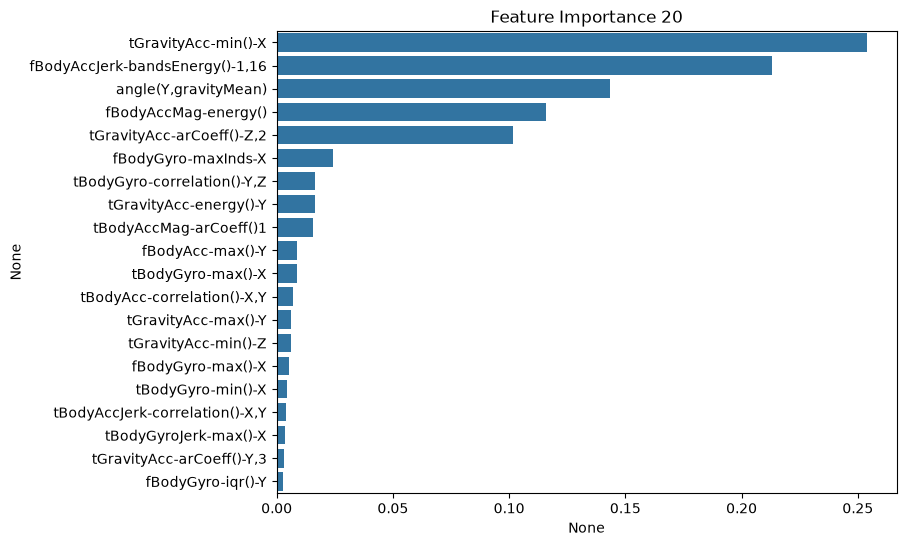

In [ ]:
import seaborn as sns

# 가장 큰 영향을 주는 feature 찾기
ftr_importances_values = best_dt_clf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index = X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize = (8, 6))
plt.title("Feature Importance 20")
sns.barplot(x = ftr_top20, y = ftr_top20.index)